In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from pyproj import Transformer

In [3]:
DATA_PATH = "divar.csv"
df = pd.read_csv(DATA_PATH)

C:\Users\IRANA COMPUTER\AppData\Local\Temp\ipykernel_27332\1138651529.py:2: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


We start by selecting features that are important for user preferences, such as price, location, building size, and number of rooms.

In [ ]:
clustering_cols = [
    "price_value",
    "building_size",
    "rooms_count",
    "location_latitude",
    "location_longitude"
]

helper_cols = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "neighborhood_slug"
]

df_cluster = df[clustering_cols + helper_cols].copy()
df_cluster.shape

(1000000, 9)

In [12]:
df_cluster[clustering_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   price_value         568346 non-null  float64
 1   building_size       980394 non-null  float64
 2   rooms_count         845899 non-null  object 
 3   location_latitude   655608 non-null  float64
 4   location_longitude  655608 non-null  float64
dtypes: float64(4), object(1)
memory usage: 38.1+ MB


In [ ]:
df_cluster['rooms_count'].value_counts()

rooms_count
دو              404050
یک              192083
سه              138633
بدون اتاق        75898
چهار             21371
پنج یا بیشتر     13864
Name: count, dtype: int64

In [14]:
rooms_mapping = {
    "بدون اتاق": 0,
    "یک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج یا بیشتر": 5
}
df_cluster["rooms_count"] = df_cluster["rooms_count"].map(rooms_mapping)

In [15]:
df_cluster['rooms_count'].value_counts()

rooms_count
2.0    404050
1.0    192083
3.0    138633
0.0     75898
4.0     21371
5.0     13864
Name: count, dtype: int64

In [16]:
df_cluster[clustering_cols].isna().mean().sort_values(ascending=False) * 100

price_value           43.1654
location_longitude    34.4392
location_latitude     34.4392
rooms_count           15.4101
building_size          1.9606
dtype: float64

We remove rows with missing values in the selected clustering features because KMeans is distance-based and imputed values may create artificial clusters.

In [17]:
df_cluster = df_cluster[
    df_cluster["price_value"].notna() &
    df_cluster["building_size"].notna() &
    df_cluster["rooms_count"].notna() &
    df_cluster["location_latitude"].notna() &
    df_cluster["location_longitude"].notna()
].copy()

we also remove unvalid values

In [18]:
df_cluster = df_cluster[
    (df_cluster["price_value"] > 0) &
    (df_cluster["building_size"] > 0)
].copy()

In [19]:
df_cluster = df_cluster[
    df_cluster["location_latitude"].between(24, 40) &
    df_cluster["location_longitude"].between(44, 64)
].copy()

In [20]:
df_cluster.shape

(299671, 9)

In [21]:
df_cluster.describe()

,price_value,building_size,rooms_count,location_latitude,location_longitude
count,2.996710e+05,2.996710e+05,299671.000000,299671.000000,299671.000000
mean,1.787546e+10,2.018157e+03,1.973678,35.149824,51.548650
std,5.984184e+11,9.857419e+04,0.922083,2.184080,3.016972
min,1.000000e+00,1.000000e+00,0.000000,24.592085,44.032516
25%,1.750000e+09,7.200000e+01,1.000000,35.330254,50.831797
50%,3.200000e+09,9.500000e+01,2.000000,35.725353,51.334583
75%,6.300000e+09,1.350000e+02,2.000000,36.300945,51.757256
max,1.000000e+14,1.000000e+07,5.000000,39.661636,62.558594


it seems there is some outliers (by comparing min values and max values)


Handling outliers

In [22]:
lower = df_cluster['price_value'].quantile(0.02)
upper = df_cluster['price_value'].quantile(0.98)
df_cluster = df_cluster[df_cluster['price_value'].between(lower, upper)].copy()

In [23]:
df_cluster.shape

(287728, 9)

In [24]:
df_cluster.describe()

,price_value,building_size,rooms_count,location_latitude,location_longitude
count,2.877280e+05,2.877280e+05,287728.000000,287728.000000,287728.000000
mean,5.069018e+09,1.575778e+03,1.954666,35.158790,51.551080
std,5.482095e+09,8.661535e+04,0.891175,2.178153,3.021235
min,2.700000e+06,1.000000e+00,0.000000,24.592085,44.032516
25%,1.800000e+09,7.100000e+01,1.000000,35.358381,50.832335
50%,3.200000e+09,9.500000e+01,2.000000,35.724606,51.329556
75%,6.000000e+09,1.300000e+02,2.000000,36.308137,51.760393
max,3.850000e+10,1.000000e+07,5.000000,39.661636,62.558594


from previous parts, we know that Price values are highly skewed, so we use log transformation to reduce the effect of extreme values.

In [25]:
df_cluster["log_price"] = np.log1p(df_cluster["price_value"])

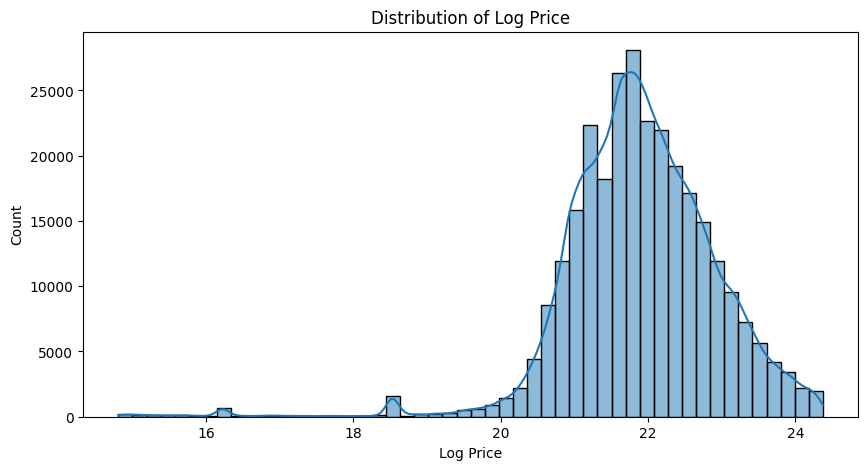

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(df_cluster["log_price"], bins=50, kde=True)

plt.title("Distribution of Log Price")
plt.xlabel("Log Price")
plt.ylabel("Count")

plt.show()

In [37]:
features_for_kmeans = [
    "log_price",
    "building_size",
    "rooms_count",
    "location_latitude",
    "location_longitude"
]

X_kmeans = df_cluster[features_for_kmeans].copy()

scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

KMeans is a distance-based algorithm, so features are scaled before clustering.

In [38]:
kmeans_10 = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

df_cluster["cluster"] = kmeans_10.fit_predict(X_kmeans_scaled)

df_cluster["cluster"].value_counts().sort_index()

cluster
0    48507
1    26833
2    73474
3     4152
4       19
5    55553
6    19900
7    22337
8    36922
9       31
Name: count, dtype: int64

In [39]:
# %%
centers_scaled = kmeans_10.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(
    centers_original,
    columns=features_for_kmeans
)

centers_df["cluster"] = range(10)

centers_df

,log_price,building_size,rooms_count,location_latitude,location_longitude,cluster
0,22.789650,4.607867e+02,1.857255,35.810288,51.113951,0
1,21.782065,5.169785e+02,2.108335,32.535364,49.869231,1
2,21.460519,2.114951e+02,2.082113,36.235345,50.634750,2
3,17.451067,4.780855e+03,1.942197,34.683922,51.202584,3
4,21.469079,9.461988e+06,0.842105,32.979037,52.372530,4
5,21.401526,8.176977e+02,0.809558,35.733538,50.464776,5
6,21.991075,1.028783e+03,2.135615,29.271640,54.417493,6
7,21.760415,8.589941e+02,1.999687,36.283394,59.184503,7
8,22.955224,4.418589e+02,3.315841,35.749161,50.679902,8
9,21.475300,3.245234e+06,1.516129,34.686383,51.754452,9


Latitude and longitude convertion to UTM

In [44]:
import utm

In [47]:
utm_x, utm_y, utm_zone_number, utm_zone_letter = utm.from_latlon(
    df_cluster["location_latitude"].values,
    df_cluster["location_longitude"].values
)

df_cluster["utm_x"] = utm_x
df_cluster["utm_y"] = utm_y
df_cluster["utm_zone_number"] = utm_zone_number
df_cluster["utm_zone_letter"] = utm_zone_letter

df_cluster[[
    "location_latitude",
    "location_longitude",
    "utm_x",
    "utm_y",
    "utm_zone_number",
    "utm_zone_letter"
]].head()

,location_latitude,location_longitude,utm_x,utm_y,utm_zone_number,utm_zone_letter
7,35.729832,51.505466,5.457116e+05,3.954101e+06,39,S
8,35.712364,50.794781,4.814371e+05,3.952066e+06,39,S
10,35.778664,51.757549,5.684670e+05,3.959664e+06,39,S
12,36.321831,59.524502,1.266003e+06,4.053542e+06,39,S
13,32.467804,51.404095,5.379740e+05,3.592362e+06,39,S


In [48]:
center_utm_x, center_utm_y, center_zone_number, center_zone_letter = utm.from_latlon(
    centers_df["location_latitude"].values,
    centers_df["location_longitude"].values
)

centers_df["utm_x"] = center_utm_x
centers_df["utm_y"] = center_utm_y
centers_df["utm_zone_number"] = center_zone_number
centers_df["utm_zone_letter"] = center_zone_letter

centers_df[[
    "cluster",
    "location_latitude",
    "location_longitude",
    "utm_x",
    "utm_y",
    "utm_zone_number",
    "utm_zone_letter"
]]

,cluster,location_latitude,location_longitude,utm_x,utm_y,utm_zone_number,utm_zone_letter
0,0,35.810288,51.113951,5.102947e+05,3.962913e+06,39,S
1,1,32.535364,49.869231,3.938152e+05,3.600343e+06,39,S
2,2,36.235345,50.634750,4.671789e+05,4.010114e+06,39,S
3,3,34.683922,51.202584,5.185569e+05,3.838011e+06,39,S
4,4,32.979037,52.372530,6.282514e+05,3.649799e+06,39,S
5,5,35.733538,50.464776,4.515995e+05,3.954527e+06,39,S
6,6,29.271640,54.417493,8.320931e+05,3.242928e+06,39,S
7,7,36.283394,59.184503,1.235753e+06,4.046603e+06,39,S
8,8,35.749161,50.679902,4.710592e+05,3.956175e+06,39,S
9,9,34.686383,51.754452,5.691073e+05,3.838524e+06,39,S
